# S5 — 視覺化精華：5 種必懂圖

> **時間**：2 小時  
> **資料**：`orders_enriched.csv` + `monthly_revenue.csv`  
> **學完能幹嘛**：把 S4 算出來的數字，變成一份可以直接丟給老闆的業績簡報

---

## 為什麼要學視覺化

**數字不會說話，圖會。** 同樣一份月度營收：

- 表格：「1月 12萬、2月 14萬、3月 9萬、4月 16萬...」 → 老闆看不出所以然
- 折線圖：一眼看出「3 月是低點，4 月反彈」

**本節原則：5 種圖夠用 90% 的場景**

| 圖 | 用途 | 範例 |
|---|---|---|
| 📈 折線圖 | 看**趨勢** | 月度營收 |
| 📊 長條圖 | 看**比較** | 各地區營收排名 |
| ⚫ 散佈圖 | 看**關聯** | 單價 vs 庫存 |
| 📦 箱型圖 | 看**分布/離群** | 各品類的金額分布 |
| 🔥 熱力圖 | 看**矩陣** | 地區 × 品類相關 |

**工具選擇**：
- **Matplotlib**：底層、可高度客製，但語法囉嗦
- **Seaborn**：建立在 Matplotlib 上，一行就很漂亮

本節以 **Seaborn 為主、Matplotlib 為輔**。


> ### 💡 知識補給站 — 好圖的三個原則 (Data-Ink Ratio)
> 
> Edward Tufte 提出的 **Data-Ink Ratio**：圖上每一滴墨水都應該傳達資訊，多餘的裝飾只會分散注意力。
> 
> **三個實用原則**：
> 1. **去雜訊**：拿掉不必要的格線、邊框、3D 效果 → 本課的 `sns.set_theme(style='whitegrid')` 已經是好的起點
> 2. **色彩有意義**：顏色要代表資訊（如 `hue=category`），不是為了好看；優先用**色盲友善**調色盤（`palette='colorblind'`）
> 3. **不要騙人**：Y 軸起點應該是 0（長條圖），不要截斷軸讓差異看起來更大 → 這叫 **"lie factor"**
> 
> 口訣：「**少即是多，每個像素都要有意義**」。
> 
> *延伸關鍵字：data-ink ratio, Tufte, lie factor, colorblind-friendly, chartjunk*

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 讓中文不亂碼（如果環境有中文字型）
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

df = pd.read_csv(
    '../datasets/ecommerce/orders_enriched.csv',
    parse_dates=['order_date'], 
)
df['month'] = df['order_date'].dt.to_period('M').astype(str)
print('資料形狀:', df.shape)

資料形狀: (188, 15)


In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from common.checker import check

---
## 圖 1／5 — 📈 折線圖：月度營收趨勢


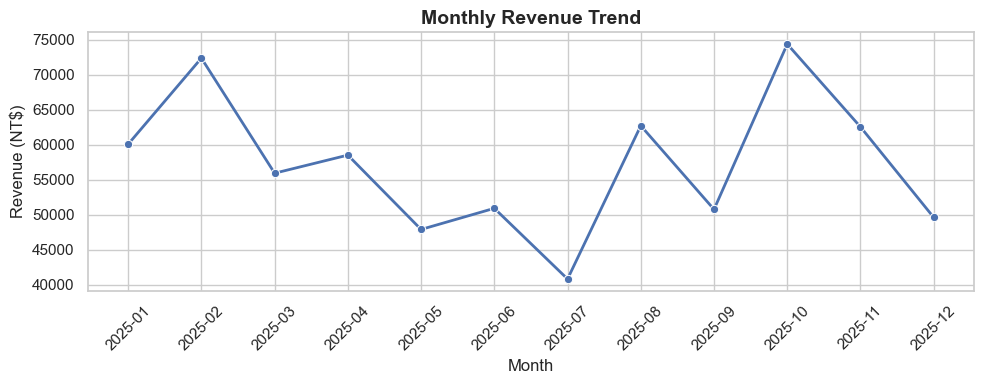

In [9]:
monthly = df.groupby('month')['amount'].sum().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly, x='month', y='amount', marker='o', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (NT$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**口訣**：趨勢用 `lineplot`，加 `marker='o'` 更清楚。


---
## 圖 2／5 — 📊 長條圖：各地區營收比較


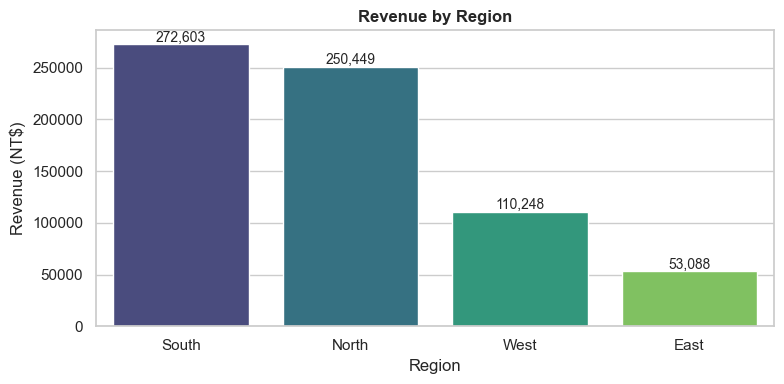

In [10]:
region_rev = df.groupby('region')['amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=region_rev, x='region', y='amount', palette='viridis', hue='region', legend=False)
plt.title('Revenue by Region', fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Revenue (NT$)')

# 在柱子上標數字
for i, v in enumerate(region_rev['amount']):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**口訣**：比較用 `barplot`，記得排序（`sort_values`），柱子上加數字。


---
## 圖 3／5 — ⚫ 散佈圖：單價 vs 訂單金額


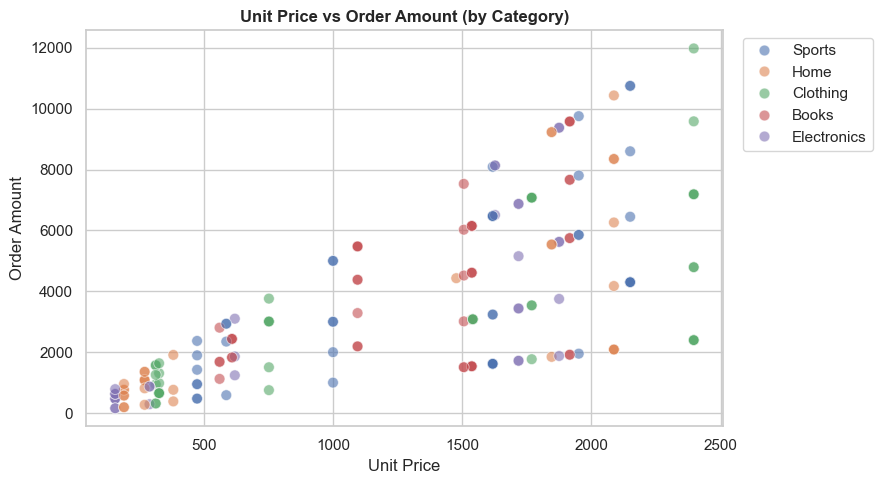

In [11]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='unit_price', y='amount',
                hue='category', alpha=0.6, s=60)
plt.title('Unit Price vs Order Amount (by Category)', fontweight='bold')
plt.xlabel('Unit Price')
plt.ylabel('Order Amount')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**口訣**：看兩個數值之間的關聯用 `scatterplot`，`hue` 可以按類別上色。


---
## 圖 4／5 — 📦 箱型圖：各品類金額分布

箱型圖能一次告訴你：中位數、四分位數、離群值。


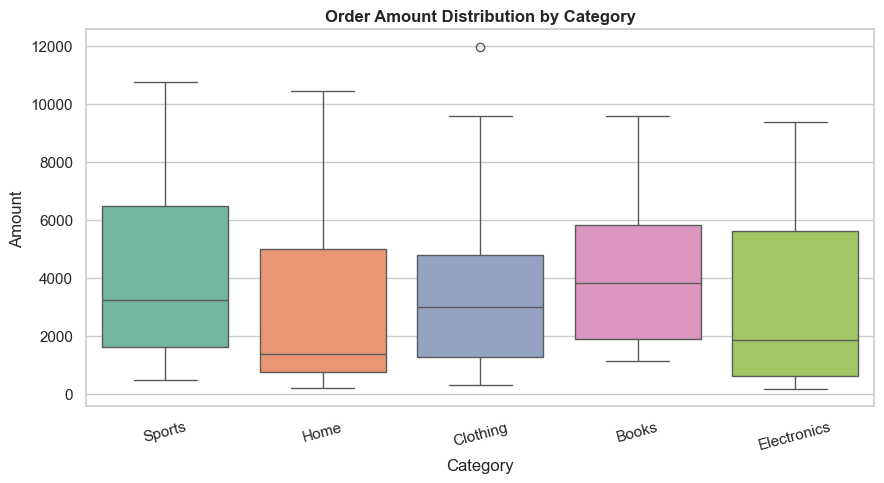

In [12]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='category', y='amount', palette='Set2', hue='category', legend=False)
plt.title('Order Amount Distribution by Category', fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**怎麼看箱型圖**：
- 盒子中間的線 = 中位數
- 盒子上下邊 = Q3 / Q1
- 上下鬚線外的點 = **離群值**（可疑資料或特殊事件）


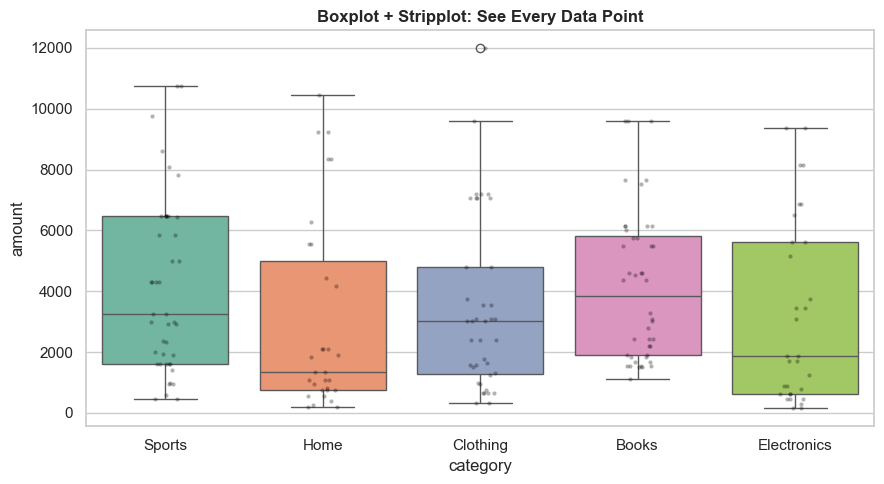

In [13]:
# 💡 知識補給站 demo — boxplot + stripplot 疊加
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='category', y='amount', palette='Set2', hue='category', legend=False)
sns.stripplot(data=df, x='category', y='amount', color='black', alpha=0.3, size=3, jitter=True)
plt.title('Boxplot + Stripplot: See Every Data Point', fontweight='bold')
plt.tight_layout()
plt.show()

> ### 💡 知識補給站 — 箱型圖的盲點：它藏了什麼？
> 
> 箱型圖很好，但它**隱藏了分布的形狀**。兩個完全不同的分布（如「常態分布」和「雙峰分布」）可能畫出**一模一樣**的箱型圖 — 因為箱型圖只看 Q1、中位數、Q3，看不到「中間有沒有凹下去」。
> 
> **解法**：搭配 `sns.stripplot()` 或 `sns.violinplot()` 看到**每個資料點的實際位置**。
> 
> 實務建議：報告中如果只放箱型圖，至少在旁邊加一句「資料呈**單峰/雙峰/右偏**分布」。
> 
> *延伸關鍵字：distribution shape, bimodal, violin plot, strip plot, data visualization pitfall*

---
## 圖 5／5 — 🔥 熱力圖：地區 × 品類營收


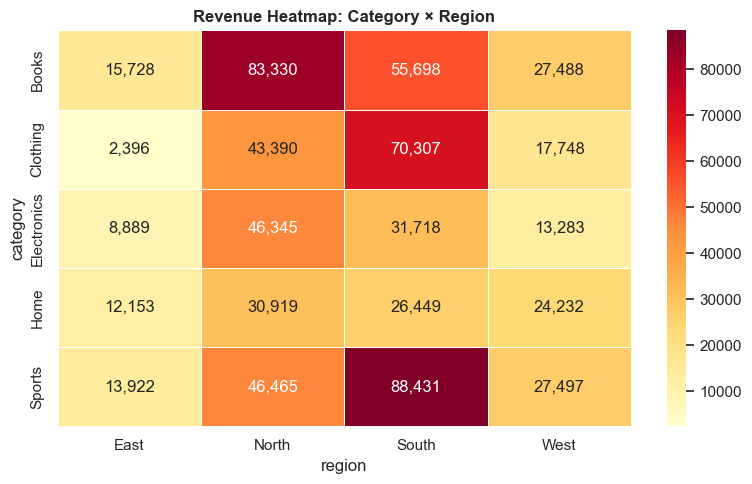

In [14]:
pivot = df.pivot_table(
    index='category', columns='region',
    values='amount', aggfunc='sum', fill_value=0,
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Revenue Heatmap: Category × Region', fontweight='bold')
plt.tight_layout()
plt.show()

**口訣**：交叉矩陣、相關係數都用 `heatmap`，`annot=True` 把數字印上去。


---
## 實務 Case — 5 張圖合成一份業績簡報

把 5 張圖畫在同一張畫布上，變成「一張投影片就能講完全局」的儀表板。


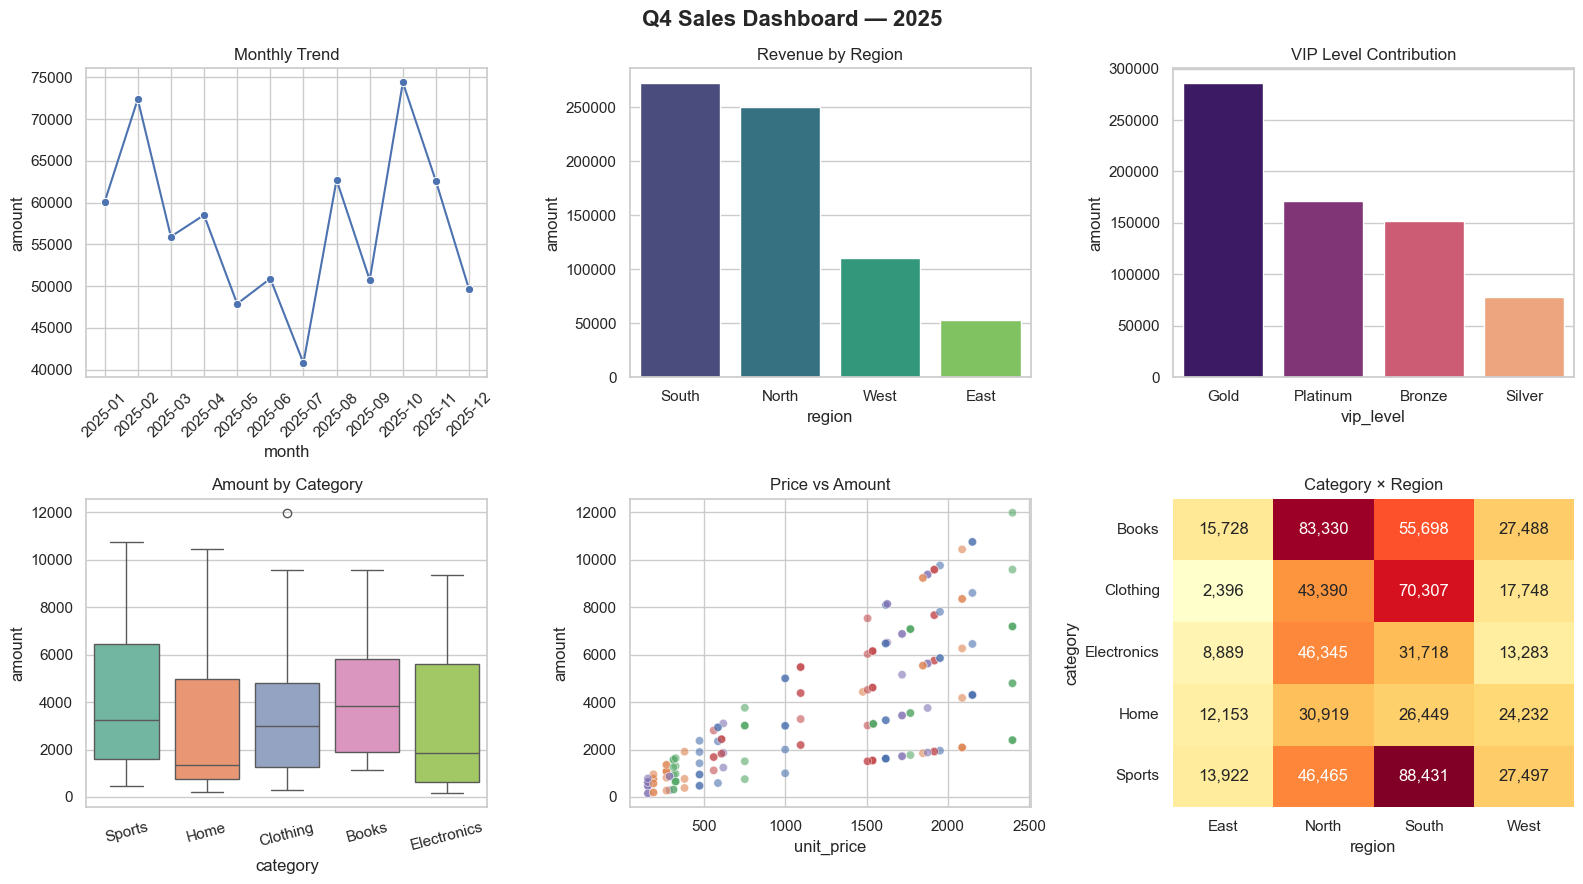

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Q4 Sales Dashboard — 2025', fontsize=16, fontweight='bold')

# (0,0) 月度趨勢
sns.lineplot(data=monthly, x='month', y='amount', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Monthly Trend')
axes[0, 0].tick_params(axis='x', rotation=45)

# (0,1) 地區排名
sns.barplot(data=region_rev, x='region', y='amount', ax=axes[0, 1],
            palette='viridis', hue='region', legend=False)
axes[0, 1].set_title('Revenue by Region')

# (0,2) VIP 貢獻
vip_rev = df.groupby('vip_level')['amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=vip_rev, x='vip_level', y='amount', ax=axes[0, 2],
            palette='magma', hue='vip_level', legend=False)
axes[0, 2].set_title('VIP Level Contribution')

# (1,0) 品類分布
sns.boxplot(data=df, x='category', y='amount', ax=axes[1, 0],
            palette='Set2', hue='category', legend=False)
axes[1, 0].set_title('Amount by Category')
axes[1, 0].tick_params(axis='x', rotation=15)

# (1,1) 單價 vs 金額散佈
sns.scatterplot(data=df, x='unit_price', y='amount',
                hue='category', alpha=0.6, ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Price vs Amount')

# (1,2) 熱力圖
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd', ax=axes[1, 2], cbar=False)
axes[1, 2].set_title('Category × Region')

plt.tight_layout()
plt.show()

🎉 恭喜！這張儀表板就是你交給老闆的成果。


---
## 課堂練習（40 min）

### 🟢 送分題
用 `df` 畫：
1. 各品類的**訂單數**長條圖
2. `amount` 的直方圖（`sns.histplot`）


In [16]:
# TODO


### 🟡 核心題
1. 畫一張**折線圖**，比較「North 地區」和「South 地區」的月度營收趨勢（兩條線）
2. 畫一張**箱型圖**，比較不同 VIP 等級的客單價


In [17]:
# TODO


### 🔴 挑戰題
做一份**「專屬於 Electronics 品類」的小型儀表板**（2×2 共 4 張圖）：
1. Electronics 的月度趨勢
2. Electronics 的地區排名
3. Electronics 的商品 Top 5（長條圖）
4. Electronics 的金額分布（histogram 或 boxplot）

> 完成後，這就是你第一份可以加進履歷的 side project。


In [18]:
# TODO


In [19]:
# 🏁 大地遊戲 — 從你的 Electronics 儀表板看，哪個地區營收最高？把 '___' 換成答案
check('S5', '___')

❌ 再想想，答案不對喔！


---
## 小結與速查表

| 想畫什麼 | 函式 |
|---|---|
| 趨勢 | `sns.lineplot(data, x, y)` |
| 比較 | `sns.barplot(data, x, y)` |
| 關聯 | `sns.scatterplot(data, x, y, hue)` |
| 分布 | `sns.histplot` / `sns.boxplot` |
| 矩陣 | `sns.heatmap(df, annot=True)` |
| 多圖組合 | `plt.subplots(nrows, ncols)` + `ax=axes[i,j]` |
| 存圖 | `plt.savefig('xxx.png', dpi=150)` |

**小白通用原則**：先用 seaborn 一行搞定，不夠漂亮再用 matplotlib 微調。

**下節預告 S6**：Matplotlib/Seaborn 畫的是**靜態圖片**，交給別人只能看不能點。S6 會學 **Plotly**，讓圖表能滑鼠 hover 看數字、縮放、篩選 → 做出真正的互動式儀表板，並完整走一遍 raw → clean → analyze → dashboard。
